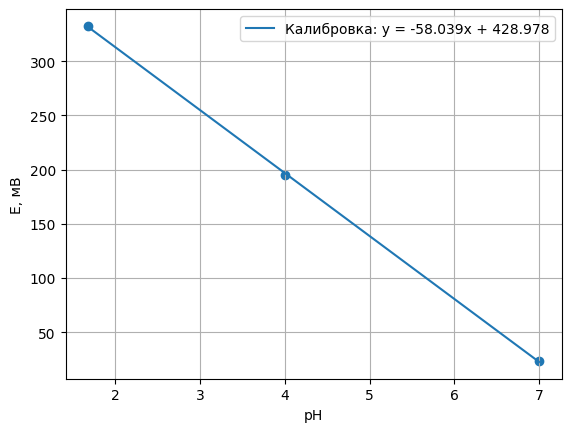

In [1]:
import numpy as np
import matplotlib.pyplot as plt
pH = np.array([1.68, 4, 7])
e = np.array([332.5, 195, 23.5])
plt.scatter(pH, e)
plt.xlabel('рН')
plt.ylabel('E, мВ')


coeffs_2 = np.polyfit(pH, e, 1)
poly_2 = np.poly1d(coeffs_2)
x_smooth = np.linspace(min(pH), max(pH), 100)
y_smooth_2 = poly_2(x_smooth)
plt.plot(x_smooth, y_smooth_2, label=f'Калибровка: y = {coeffs_2[0]:.3f}x + {coeffs_2[1]:.3f}')
plt.legend()
plt.grid()
plt.savefig('kalibr.png')
plt.show()

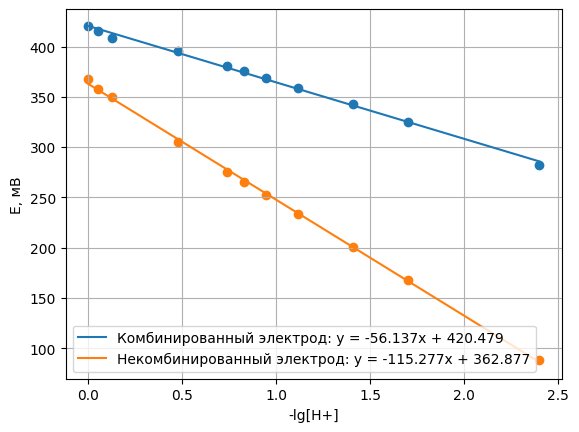

In [2]:
es = np.array([282.5, 325, 342.5, 359, 369.1, 375.8, 381,396, 408.9, 415.7, 420.1])
des = np.array([88.4, 168, 200.9, 233.2, 252.4, 265, 275, 305, 350, 357.5, 367.5])
v = np.array([0.1, 0.5, 1, 2, 3, 4, 5, 10, 30, 40, 50])

#es = np.array([282.5, 325, 342.5, 359, 369.1, 375.8, 381,396, 415.7, 420.1])
#des = np.array([88.4, 168, 200.9, 233.2, 252.4, 265, 275, 305, 357.5, 367.5])
#v = np.array([0.1, 0.5, 1, 2, 3, 4, 5, 10, 40, 50])

c = ((v*0.002)/(v+50))*1000
x = np.log10(c)
x = -x


plt.scatter(x, es)
plt.xlabel('-lg[H+]')
plt.ylabel('E, мВ')

plt.scatter(x, des)
plt.xlabel('-lg[H+]')
plt.ylabel('E, мВ')

coeffs_2 = np.polyfit(x, es, 1)
poly_2 = np.poly1d(coeffs_2)
x_smooth = np.linspace(min(x), max(x), 100)
y_smooth_2 = poly_2(x_smooth)
plt.plot(x_smooth, y_smooth_2, label=f'Комбинированный электрод: y = {coeffs_2[0]:.3f}x + {coeffs_2[1]:.3f}')

coeffs_21 = np.polyfit(x, des, 1)
poly_21 = np.poly1d(coeffs_21)
x_smooth1 = np.linspace(min(x), max(x), 100)
y_smooth_21 = poly_21(x_smooth1)
plt.plot(x_smooth1, y_smooth_21, label=f'Некомбинированный электрод: y = {coeffs_21[0]:.3f}x + {coeffs_21[1]:.3f}')

plt.legend()
plt.grid()
plt.savefig('elektr_sravn.png')
plt.show()

<>:5: SyntaxWarning: invalid escape sequence '\o'
<>:5: SyntaxWarning: invalid escape sequence '\o'
C:\Users\User\AppData\Local\Temp\ipykernel_18120\2533641907.py:5: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('$\omega$, В')


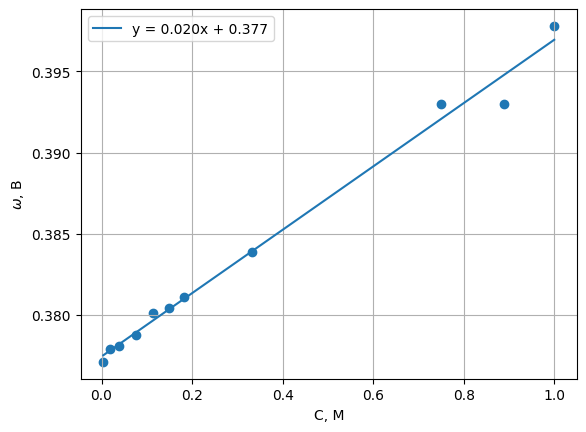

In [3]:
y = des/1000 - 2*8.314*299.5*np.log(10)*np.log10(c)/96485 + 2*8.314*299.5*np.log(10)*0.51*np.sqrt(c)/(96485*(1+np.sqrt(c)))

plt.scatter(c, y)
plt.xlabel('C, М')
plt.ylabel('$\omega$, В')

coeffs_2 = np.polyfit(c, y, 1)
poly_2 = np.poly1d(coeffs_2)
x_smooth = np.linspace(min(c), max(c), 100)
y_smooth_2 = poly_2(x_smooth)
plt.plot(x_smooth, y_smooth_2, label=f'y = {coeffs_2[0]:.3f}x + {coeffs_2[1]:.3f}')

plt.legend()
plt.grid()
plt.savefig('big_formula.png')
plt.show()

<>:35: SyntaxWarning: invalid escape sequence '\g'
<>:35: SyntaxWarning: invalid escape sequence '\g'
C:\Users\User\AppData\Local\Temp\ipykernel_18120\4246888489.py:35: SyntaxWarning: invalid escape sequence '\g'
  plt.ylabel('$lg(\gamma \pm)$, В')


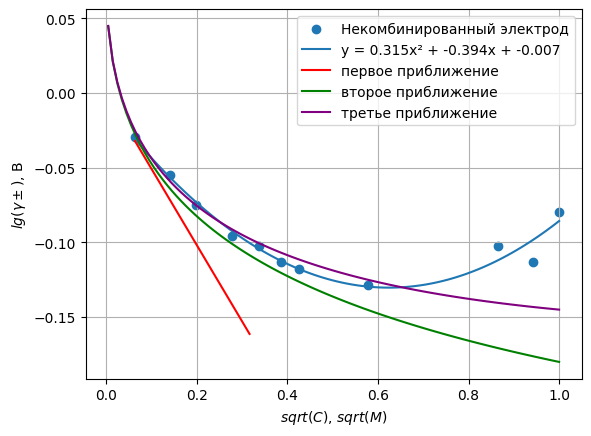

In [4]:
lg_gamma = ((des/1000 - 0.377)*96485)/(2*8.314*299.5*np.log(10)) - np.log10(c)

sqrt_ion = np.sqrt(c)

plt.scatter(sqrt_ion, lg_gamma, label='Некомбинированный электрод')


coeffs_2 = np.polyfit(sqrt_ion, lg_gamma, 2)
poly_2 = np.poly1d(coeffs_2)
x_smooth = np.linspace(min(sqrt_ion), max(sqrt_ion), 100)
y_smooth_2 = poly_2(x_smooth)
plt.plot(x_smooth, y_smooth_2, label=f'y = {coeffs_2[0]:.3f}x² + {coeffs_2[1]:.3f}x + {coeffs_2[2]:.3f}')

c_dh = np.linspace(0.00399202, max(c)/10, 100)
dh_1 = -0.51*np.sqrt(c_dh)
plt.plot(np.sqrt(c_dh), dh_1, color='red', label="первое приближение")

c_dh = np.linspace(0.00399202, max(c), 100)
dh_2 = -0.51*np.sqrt(c_dh)/(1+np.sqrt(c_dh)) + 0.075
plt.plot(c_dh, dh_2, color='green', label="второе приближение")

c_dh = np.linspace(0.00399202, max(c), 100)
dh_3 = -0.51*np.sqrt(c_dh)/(1+np.sqrt(c_dh)) + c_dh*0.035 + 0.075
plt.plot(c_dh, dh_3, color='purple', label="третье приближение")


a = -58.039
b = 428.978
log_gamma = (es - b) / (a*1000) - np.log10(c)

#ionic_strength = c
#sqrt_ionic = np.sqrt(ionic_strength)
#plt.scatter(sqrt_ionic, log_gamma, label='Комбинированный электрод')
plt.xlabel('$sqrt(C)$, $sqrt(М)$')
plt.ylabel('$lg(\gamma \pm)$, В')

plt.legend()
plt.grid()
plt.savefig('lg_gamma.png')
plt.show()

Первое приближение - до ~0.01 М
Второе приближение - до ~0.6 M
Третье приближение - до ~0.9 M

In [5]:
c

array([0.00399202, 0.01980198, 0.03921569, 0.07692308, 0.11320755,
       0.14814815, 0.18181818, 0.33333333, 0.75      , 0.88888889,
       1.        ])

<>:5: SyntaxWarning: invalid escape sequence '\g'
<>:5: SyntaxWarning: invalid escape sequence '\g'
C:\Users\User\AppData\Local\Temp\ipykernel_18120\537480200.py:5: SyntaxWarning: invalid escape sequence '\g'
  plt.ylabel('$lg(\gamma \pm)$, В')


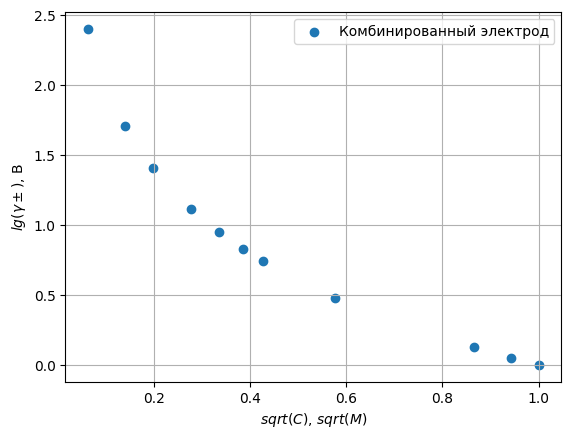

In [6]:
ionic_strength = c
sqrt_ionic = np.sqrt(ionic_strength)
plt.scatter(sqrt_ionic, log_gamma, label='Комбинированный электрод')
plt.xlabel('$sqrt(C)$, $sqrt(М)$')
plt.ylabel('$lg(\gamma \pm)$, В')


plt.legend()
plt.grid()

plt.show()

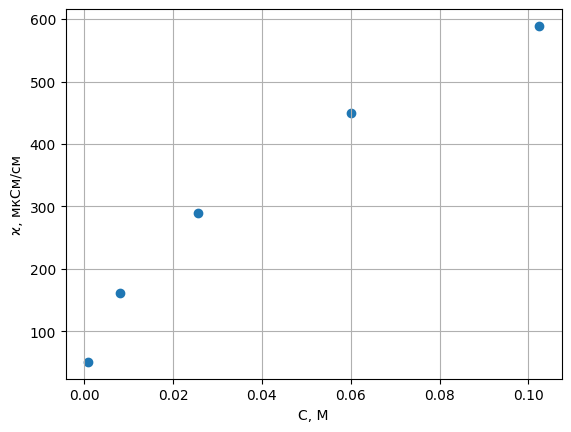

In [7]:
kappa = np.array([51, 162, 289, 450, 589])
sqrt_c = np.array([0.03, 0.09, 0.16, 0.245, 0.32])

plt.scatter(sqrt_c**2, kappa)
plt.xlabel('C, М')
plt.ylabel('ϰ, мкСм/см')

#plt.legend()
plt.grid()
plt.savefig('kappa_c.png')
plt.show()

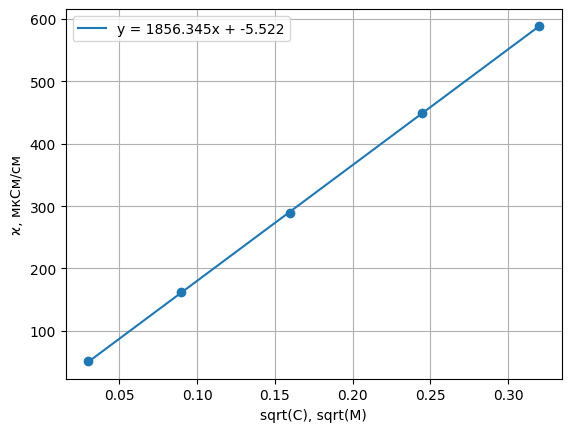

In [8]:
plt.scatter(sqrt_c, kappa)
plt.xlabel('sqrt(C), sqrt(М)')
plt.ylabel('ϰ, мкСм/см')

coeffs_2 = np.polyfit(sqrt_c, kappa, 1)
poly_2 = np.poly1d(coeffs_2)
x_smooth = np.linspace(min(sqrt_c), max(sqrt_c), 100)
y_smooth_2 = poly_2(x_smooth)
plt.plot(x_smooth, y_smooth_2, label=f'y = {coeffs_2[0]:.3f}x + {coeffs_2[1]:.3f}')

plt.legend()
plt.grid()
plt.savefig('kappa_sqrt_c.png')
plt.show()